# 06 — Dual-timescale representation

**Experimental only.** `src/inference.py`, the frozen artifacts, the API, the dashboard and notebooks
01–05 are untouched. The adaptive threshold is used exactly as production defines it — the immune
variant from notebook 05 is rejected and is not revisited here.

## The question

Notebook 05 found a clean tradeoff for `acc_w4` (|trailing 4-obs mean of `clim_dev`|, max across
variables), on held-out seeds:

| | bias F1 | spike episode recall |
|---|---|---|
| baseline 16 | 0.221 | 0.892 |
| + `acc_w4` | **0.338** | **0.825** (−0.067 ± 0.023, consistent) |

The proposed explanation — **a 4-observation average helps persistent signals and dilutes short
transients** — was a hypothesis, not a measured cause. This notebook tests it, and tests whether
carrying a short-timescale signal alongside the medium one recovers the loss.

## Protocol carried over unchanged

Exploration seeds **11/22/33** (selection only, already frozen — nothing new is selected here).
Held-out seeds **44/55/66** for the bias sweep. Challenge benchmark across **5 seeds**. Same
hyperparameters, same training slice, same threshold.

In [1]:
import sys, os, itertools, warnings
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../src")
from fault_injection import FaultSimulator, legacy_inject, CHALLENGE_CONFIG, VARS
from inference import WeatherFaultDetector
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, roc_auc_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 210); pd.set_option("display.max_columns", 60)

HELDOUT_SEEDS  = [44, 55, 66]
CHALLENGE_SEEDS = [42, 101, 202, 303, 404]
SIGMAS = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
ONSETS = ["step", "ramp"]
N_EP, EP_LEN, RAMP_LEN, W = 10, 16, 4, 4

TRANSIENT  = ["spike", "intermittent_spikes"]
PERSISTENT = ["bias", "drift", "stuck_at", "noise_burst", "drift_plus_noise", "bias_plus_spikes"]

raw = pd.read_csv("../data/processed/vidd_2023_clean.csv", parse_dates=["time"])
df = raw.drop(columns=["station", "dew_c", "dew_qc"]).sort_values("time").reset_index(drop=True)
df[VARS] = (df.set_index("time")[VARS]
              .interpolate(method="time", limit=2, limit_direction="both").to_numpy())
n = len(df)

det = WeatherFaultDetector.load("../models")
FEATS16 = list(det.features)
SPLIT   = int(0.70 * n)
CONTAM  = float(det.manifest["model"]["contamination"])
N_EST   = int(det.manifest["model"]["n_estimators"])
RSTATE  = int(det.manifest["model"]["random_state"])
print(f"frozen: {N_EST} trees, contamination {CONTAM:.6f}, seed {RSTATE}, {len(FEATS16)} features")

frozen: 200 trees, contamination 0.062438, seed 42, 16 features


## 1. Is condition C actually a separate model?

`clim_short = max_v |clim_dev_v|` is a **deterministic function** of three features already in the
set, so it carries **no new information**. That is not the same as being redundant to the model.

The Isolation Forest splits on one feature at a time, and `max(|a|,|b|,|c|)` is not an axis-parallel
function — no single split can express it. The check below quantifies how differently it behaves from
anything already present. If it were near-duplicate, C would be omitted rather than dressed up as a
distinct condition.

In [2]:
_ft = det._build_features(df[["time"] + VARS].copy())
CD = [f"{v}_clim_dev" for v in VARS]
_short = _ft[CD].abs().max(axis=1)

dup = [c for c in FEATS16 if np.allclose(_short, _ft[c])]
cor = _ft[FEATS16].corrwith(_short).abs().sort_values(ascending=False)
from sklearn.linear_model import LinearRegression
r2 = LinearRegression().fit(_ft[CD], _short).score(_ft[CD], _short)

print("condition C - redundancy audit")
print(f"  exact duplicate of an existing feature : {dup if dup else 'none'}")
print(f"  max |correlation| with any of the 16   : {cor.max():.4f}  ({cor.index[0]})")
print(f"  linear R^2 on the 3 signed clim_dev    : {r2:.4f}")
print("  information content                    : redundant (a function of existing columns)")
print("  representation for an axis-parallel tree: NOT redundant (max-abs needs many splits)")
print("\n  -> C is retained as a distinct condition, with that caveat stated in the findings.")

condition C - redundancy audit
  exact duplicate of an existing feature : none
  max |correlation| with any of the 16   : 0.1138  (temp_c_roll_std)
  linear R^2 on the 3 signed clim_dev    : 0.0105
  information content                    : redundant (a function of existing columns)
  representation for an axis-parallel tree: NOT redundant (max-abs needs many splits)

  -> C is retained as a distinct condition, with that caveat stated in the findings.


## 2. Feature definitions and models

Two added features, both past-only:

* **SHORT** `clim_short = max_v |clim_dev_v|` — instantaneous, no averaging.
* **MEDIUM** `acc_w4 = max_v |trailing 4-obs mean of clim_dev_v|` — the notebook-05 selection.

Nothing else is added. No search is performed in this notebook.

In [3]:
def add_feats(ft):
    cols = {}
    cols["clim_short"] = ft[CD].abs().max(axis=1).fillna(0.0)
    acc = [ft[c].rolling(W, min_periods=max(2, W // 3)).mean().abs() for c in CD]
    cols[f"acc_w{W}"] = pd.concat(acc, axis=1).max(axis=1).fillna(0.0)
    return pd.DataFrame(cols, index=ft.index)

SHORT, MED = "clim_short", f"acc_w{W}"
CONDITIONS = {
    "A baseline (16)":            FEATS16,
    "B +acc_w4 (17)":             FEATS16 + [MED],
    "C +clim_short (17)":         FEATS16 + [SHORT],
    "D dual-timescale (18)":      FEATS16 + [SHORT, MED],
}

legacy_faulty, legacy_labels, legacy_eps = legacy_inject(df, seed=42)
tr_ft = det._build_features(legacy_faulty[["time"] + VARS].copy())
TRAIN = pd.concat([tr_ft[FEATS16], add_feats(tr_ft)], axis=1)

MODELS = {}
for name, feats in CONDITIONS.items():
    MODELS[name] = IsolationForest(n_estimators=N_EST, contamination=CONTAM,
                                   random_state=RSTATE, n_jobs=-1).fit(TRAIN[feats].iloc[:SPLIT])
    print(f"  {name:26s} {len(feats)} features")


def build_X(frame):
    ft = det._build_features(frame[["time"] + VARS].copy())
    return pd.concat([ft[FEATS16], add_feats(ft)], axis=1), ft


def run(cond, frame, X=None, ft=None):
    if X is None:
        X, ft = build_X(frame)
    s = -MODELS[cond].score_samples(X[CONDITIONS[cond]])
    thr = det._adaptive_threshold(frame["time"], s)          # production threshold, unchanged
    flat, _ = det._flat_run_flags(ft)
    if_pred = (s > thr).astype(int)
    return dict(score=s, thr=thr, pred=((if_pred + flat.astype(int)) > 0).astype(int))

  A baseline (16)            16 features
  B +acc_w4 (17)             17 features


  C +clim_short (17)         17 features
  D dual-timescale (18)      18 features


## 3. Feature diagnostics — does averaging actually suppress transients?

The hypothesis is visual before it is statistical. Below: `clim_short` and `acc_w4` around a single
spike, and around a persistent bias, on the same axes.

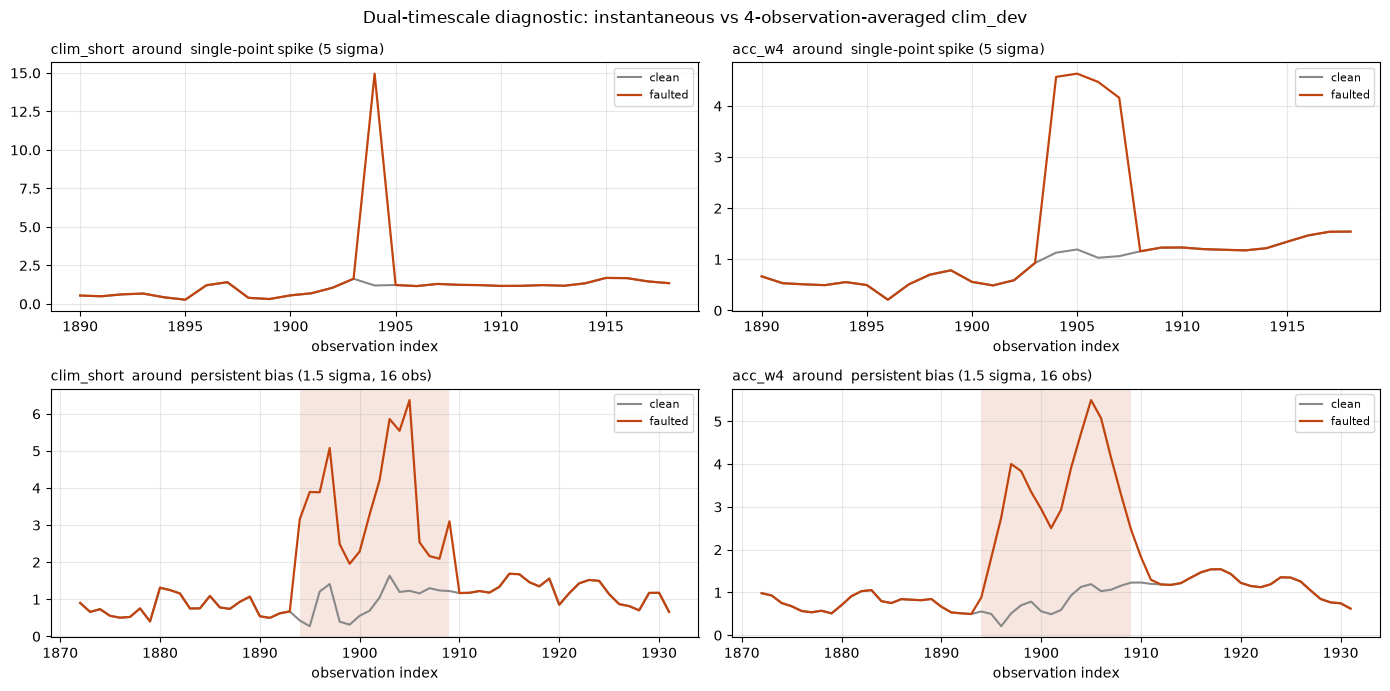

In [4]:
sp_f, sp_l, sp_e = FaultSimulator(df, seed=HELDOUT_SEEDS[0]).inject(
    [{"type": "spike", "variables": ["temp_c"], "n_per_var": 6, "length": (1, 1),
      "params": {"magnitude": (5.0, 5.0), "shape": "point", "direction": "positive"}}])
bi_f, bi_l, bi_e = FaultSimulator(df, seed=HELDOUT_SEEDS[0]).inject(
    [{"type": "bias", "variables": ["temp_c"], "n_per_var": 6, "length": (EP_LEN, EP_LEN),
      "params": {"magnitude": (1.5, 1.5), "onset": "step", "direction": "positive"}}])
Xs, _ = build_X(sp_f); Xb, _ = build_X(bi_f); Xc, _ = build_X(df)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for row, (X, eps, title, pad) in enumerate([(Xs, sp_e, "single-point spike (5 sigma)", 14),
                                            (Xb, bi_e, "persistent bias (1.5 sigma, 16 obs)", 22)]):
    e = eps.iloc[0]; lo = max(0, e.start_idx - pad); hi = min(n, e.end_idx + pad + 1)
    xr = range(lo, hi)
    for col, feat in enumerate([SHORT, MED]):
        ax = axes[row][col]
        ax.plot(xr, Xc[feat].to_numpy()[lo:hi], lw=1.5, color="#888", label="clean")
        ax.plot(xr, X[feat].to_numpy()[lo:hi], lw=1.6, color="#c1440e", label="faulted")
        ax.axvspan(e.start_idx, e.end_idx, color="#c1440e", alpha=.13, lw=0)
        ax.set_title(f"{feat}  around  {title}", fontsize=10, loc="left")
        ax.grid(alpha=.3); ax.legend(fontsize=8); ax.set_xlabel("observation index")
fig.suptitle("Dual-timescale diagnostic: instantaneous vs 4-observation-averaged clim_dev", fontsize=12)
fig.tight_layout(); plt.show()

In [5]:
# quantified version of the same picture: peak response per fault type
rows = []
SPECS = {
    "spike":       [{"type": "spike", "variables": ["temp_c"], "n_per_var": 12, "length": (1, 1),
                     "params": {"magnitude": (5.0, 5.0), "shape": "point", "direction": "random"}}],
    "bias(1.5s)":  [{"type": "bias", "variables": ["temp_c"], "n_per_var": 12, "length": (EP_LEN, EP_LEN),
                     "params": {"magnitude": (1.5, 1.5), "onset": "step", "direction": "random"}}],
    "drift(3s)":   [{"type": "drift", "variables": ["temp_c"], "n_per_var": 12, "length": (EP_LEN, EP_LEN),
                     "params": {"magnitude": (3.0, 3.0), "exponent": 1.0, "direction": "random"}}],
    "noise_burst": [{"type": "noise_burst", "variables": ["temp_c"], "n_per_var": 12, "length": (12, 12),
                     "params": {"level": "medium", "magnitude": (1.0, 1.0)}}],
}
for label, cfg in SPECS.items():
    f, l, e = FaultSimulator(df, seed=HELDOUT_SEEDS[0]).inject(cfg)
    X, _ = build_X(f); y = l.is_fault.to_numpy().astype(bool)
    for feat in [SHORT, MED]:
        b = X[feat].to_numpy(); c = Xc[feat].to_numpy()
        rows.append(dict(fault=label, feature=feat,
                         peak_response=float(np.mean(b[y]) - np.mean(c[y])),
                         auc=float(roc_auc_score(y, b))))
resp = pd.DataFrame(rows).pivot(index="fault", columns="feature",
                                values=["peak_response", "auc"]).round(3)
resp[("advantage", "")] = [
    "short" if resp.loc[i, ("auc", SHORT)] > resp.loc[i, ("auc", MED)] else "medium"
    for i in resp.index]
print("FEATURE RESPONSE BY FAULT TYPE  (auc = row-level separation of that feature alone)\n")
print(resp.to_string())
print("\nexpected advantage: transient faults favour the instantaneous signal,")
print("persistent faults favour the averaged one - this table tests that directly.")

FEATURE RESPONSE BY FAULT TYPE  (auc = row-level separation of that feature alone)

            peak_response               auc            advantage
feature            acc_w4 clim_short acc_w4 clim_short          
fault                                                           
bias(1.5s)          2.226      2.397  0.957      0.963     short
drift(3s)           2.264      2.698  0.877      0.903     short
noise_burst         0.842      2.400  0.738      0.872     short
spike               1.783      8.274  0.843      1.000     short

expected advantage: transient faults favour the instantaneous signal,
persistent faults favour the averaged one - this table tests that directly.


## 4. Bias sweep — held-out seeds

In [6]:
def bias_cfg(var, sg, onset):
    p = {"magnitude": (sg, sg), "onset": onset, "direction": "random"}
    if onset == "ramp":
        p["onset_len"] = RAMP_LEN
    return [{"type": "bias", "variables": [var], "n_per_var": N_EP,
             "length": (EP_LEN, EP_LEN), "params": p}]

recs = []
for var, sg, onset, seed in itertools.product(VARS, SIGMAS, ONSETS, HELDOUT_SEEDS):
    f, l, e = FaultSimulator(df, seed=seed).inject(bias_cfg(var, sg, onset))
    X, ft = build_X(f); y = l.is_fault.to_numpy(); eid = l.episode_id.to_numpy()
    for cond in CONDITIONS:
        R = run(cond, f, X, ft)
        p, r, f1, _ = precision_recall_fscore_support(y, R["pred"], average="binary",
                                                      pos_label=1, zero_division=0)
        dets, dly = [], []
        for ep in e.itertuples():
            idx = np.flatnonzero((eid == ep.episode_id) & (y == 1))
            hit = idx[R["pred"][idx] == 1]
            dets.append(hit.size > 0); dly.append(hit.min() - idx.min() if hit.size else np.nan)
        recs.append(dict(condition=cond, variable=var, sigma=sg, onset=onset, seed=seed,
                         precision=p, recall=r, f1=f1, episode_recall=float(np.mean(dets)),
                         alert_rate=float(R["pred"].mean()),
                         delay_obs=float(np.nanmedian(dly))))
bias_sweep = pd.DataFrame(recs)

bs = (bias_sweep.groupby("condition")
      .agg(precision=("precision", "mean"), recall=("recall", "mean"), f1=("f1", "mean"),
           episode_recall=("episode_recall", "mean"), alert_rate=("alert_rate", "mean"),
           delay_obs=("delay_obs", "mean")).round(4))
print("BIAS SWEEP - held-out seeds, all magnitudes pooled\n")
print(bs.to_string())
print("\nsubtle regime only (<= 2 sigma):\n")
print(bias_sweep[bias_sweep.sigma <= 2].groupby(["condition", "sigma"])
      [["episode_recall", "recall", "precision"]].mean().round(4).to_string())

BIAS SWEEP - held-out seeds, all magnitudes pooled

                       precision  recall      f1  episode_recall  alert_rate  delay_obs
condition                                                                              
A baseline (16)           0.1867  0.2717  0.2210          0.8380      0.0790     2.8796
B +acc_w4 (17)            0.2819  0.4248  0.3384          0.8787      0.0822     2.9167
C +clim_short (17)        0.2913  0.4311  0.3473          0.8824      0.0805     2.3287
D dual-timescale (18)     0.3469  0.4877  0.4050          0.8917      0.0766     2.2315

subtle regime only (<= 2 sigma):

                             episode_recall  recall  precision
condition             sigma                                   
A baseline (16)       0.5            0.6500  0.1057     0.0766
                      1.0            0.7111  0.1582     0.1149
                      1.5            0.8167  0.2129     0.1539
                      2.0            0.9278  0.2753     0.1960
B +acc_

## 5. Challenge benchmark — all eight fault classes, five seeds

In [7]:
rows, cls_rows, dly_rows = [], [], []
for seed in CHALLENGE_SEEDS:
    cf, cl, ce = FaultSimulator(df, seed=seed).inject(CHALLENGE_CONFIG)
    X, ft = build_X(cf); y = cl.is_fault.to_numpy(); eid = cl.episode_id.to_numpy()
    for cond in CONDITIONS:
        R = run(cond, cf, X, ft)
        p, r, f1, _ = precision_recall_fscore_support(y, R["pred"], average="binary",
                                                      pos_label=1, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y, R["pred"], labels=[0, 1]).ravel()
        rows.append(dict(seed=seed, condition=cond, precision=p, recall=r, f1=f1,
                         alert_rate=float(R["pred"].mean()), fpr=fp / (fp + tn)))
        for ep in ce.itertuples():
            idx = np.flatnonzero((eid == ep.episode_id) & (y == 1))
            hit = idx[R["pred"][idx] == 1]
            cls_rows.append(dict(seed=seed, condition=cond, fault_type=ep.fault_type,
                                 detected=float(hit.size > 0)))
            dly_rows.append(dict(seed=seed, condition=cond, fault_type=ep.fault_type,
                                 family="transient" if ep.fault_type in TRANSIENT else "persistent",
                                 delay=float(hit.min() - idx.min()) if hit.size else np.nan))
chal = pd.DataFrame(rows); cls = pd.DataFrame(cls_rows); dly = pd.DataFrame(dly_rows)

print("CHALLENGE BENCHMARK - mean +- sd over 5 seeds\n")
print(chal.groupby("condition")[["precision", "recall", "f1", "alert_rate", "fpr"]]
      .agg(["mean", "std"]).round(4).to_string())

print("\nPER-CLASS EPISODE RECALL (mean over 5 seeds)\n")
pc = cls.groupby(["fault_type", "condition"]).detected.mean().unstack().round(3)
print(pc.to_string())

base = "A baseline (16)"
print(f"\nDIFFERENCE vs baseline, mean +- seed-to-seed sd  (|mean| > sd = consistent)\n")
pv = cls.pivot_table(index=["fault_type", "seed"], columns="condition", values="detected").reset_index()
out = []
for c in CONDITIONS:
    if c == base:
        continue
    pv["d"] = pv[c] - pv[base]
    g = pv.groupby("fault_type").d.agg(["mean", "std"])
    for ftp, r_ in g.iterrows():
        out.append(dict(condition=c, fault_type=ftp, diff=round(r_["mean"], 3),
                        sd=round(r_["std"], 3),
                        consistent="YES" if abs(r_["mean"]) > r_["std"] and r_["mean"] != 0 else ""))
print(pd.DataFrame(out).pivot(index="fault_type", columns="condition",
                              values=["diff", "sd"]).round(3).to_string())
print("\nconsistent changes (|mean| > seed sd):")
cons = pd.DataFrame(out).query("consistent=='YES'")
print(cons[["condition", "fault_type", "diff", "sd"]].to_string(index=False) if len(cons) else "   none")

CHALLENGE BENCHMARK - mean +- sd over 5 seeds

                      precision          recall              f1         alert_rate             fpr        
                           mean     std    mean     std    mean     std       mean     std    mean     std
condition                                                                                                 
A baseline (16)          0.5921  0.0180  0.4194  0.0281  0.4908  0.0252     0.0957  0.0029  0.0451  0.0012
B +acc_w4 (17)           0.6054  0.0101  0.4307  0.0144  0.5032  0.0121     0.0962  0.0016  0.0439  0.0015
C +clim_short (17)       0.6479  0.0174  0.4560  0.0240  0.5351  0.0214     0.0951  0.0025  0.0387  0.0016
D dual-timescale (18)    0.6717  0.0162  0.4684  0.0231  0.5517  0.0179     0.0943  0.0035  0.0358  0.0024

PER-CLASS EPISODE RECALL (mean over 5 seeds)

condition            A baseline (16)  B +acc_w4 (17)  C +clim_short (17)  D dual-timescale (18)
fault_type                                                   

### Detection delay, transient and persistent reported separately

In [8]:
dsum = (dly.groupby(["condition", "family"]).delay
        .agg(median="median", mean="mean", n="size").round(3).unstack(level=1))
print("DETECTION DELAY (observations; x3 = hours). Transient and persistent NOT mixed.\n")
print(dsum.to_string())
print("\nby class:\n")
print(dly.groupby(["fault_type", "condition"]).delay.median().unstack().round(2).to_string())

DETECTION DELAY (observations; x3 = hours). Transient and persistent NOT mixed.

                          median                 mean                    n          
family                persistent transient persistent transient persistent transient
condition                                                                           
A baseline (16)              1.0       0.0      2.802     0.095        150       150
B +acc_w4 (17)               1.0       0.0      3.308     0.047        150       150
C +clim_short (17)           1.0       0.0      2.744     0.036        150       150
D dual-timescale (18)        1.0       0.0      2.943     0.036        150       150

by class:

condition            A baseline (16)  B +acc_w4 (17)  C +clim_short (17)  D dual-timescale (18)
fault_type                                                                                     
bias                             3.0             5.0                 3.5                    3.0
bias_plus_spikes        

## 6. Does the forest actually use both features?

Isolation Forest has no principled built-in feature importance, so none is invented. Instead a
**permutation sensitivity** test: shuffle one added feature, rescore, and measure how much detection
changes. A feature the model ignores can be destroyed with no effect.

In [9]:
rng = np.random.default_rng(0)
cf, cl, ce = FaultSimulator(df, seed=CHALLENGE_SEEDS[0]).inject(CHALLENGE_CONFIG)
X, ft = build_X(cf); y = cl.is_fault.to_numpy()
rows = []
for cond in ["B +acc_w4 (17)", "C +clim_short (17)", "D dual-timescale (18)"]:
    base_pred = run(cond, cf, X, ft)["pred"]
    b_f1 = precision_recall_fscore_support(y, base_pred, average="binary", zero_division=0)[2]
    for feat in CONDITIONS[cond]:
        if feat in FEATS16:
            continue
        Xp = X.copy(); Xp[feat] = rng.permutation(Xp[feat].to_numpy())
        s = -MODELS[cond].score_samples(Xp[CONDITIONS[cond]])
        thr = det._adaptive_threshold(cf["time"], s)
        flat, _ = det._flat_run_flags(ft)
        pred = (((s > thr).astype(int) + flat.astype(int)) > 0).astype(int)
        f1p = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)[2]
        rows.append(dict(condition=cond, permuted=feat, f1_intact=round(b_f1, 4),
                         f1_permuted=round(f1p, 4), drop=round(b_f1 - f1p, 4),
                         score_shift=round(float(np.mean(np.abs(
                             s - -MODELS[cond].score_samples(X[CONDITIONS[cond]])))), 5)))
perm = pd.DataFrame(rows)
print("PERMUTATION SENSITIVITY - larger drop = the model relies on that feature more\n")
print(perm.to_string(index=False))

PERMUTATION SENSITIVITY - larger drop = the model relies on that feature more

            condition   permuted  f1_intact  f1_permuted   drop  score_shift
       B +acc_w4 (17)     acc_w4     0.4940       0.4375 0.0565      0.00813
   C +clim_short (17) clim_short     0.5449       0.4536 0.0913      0.00761
D dual-timescale (18) clim_short     0.5515       0.4918 0.0598      0.00726
D dual-timescale (18)     acc_w4     0.5515       0.5310 0.0205      0.00643


## 7. Plots for the report

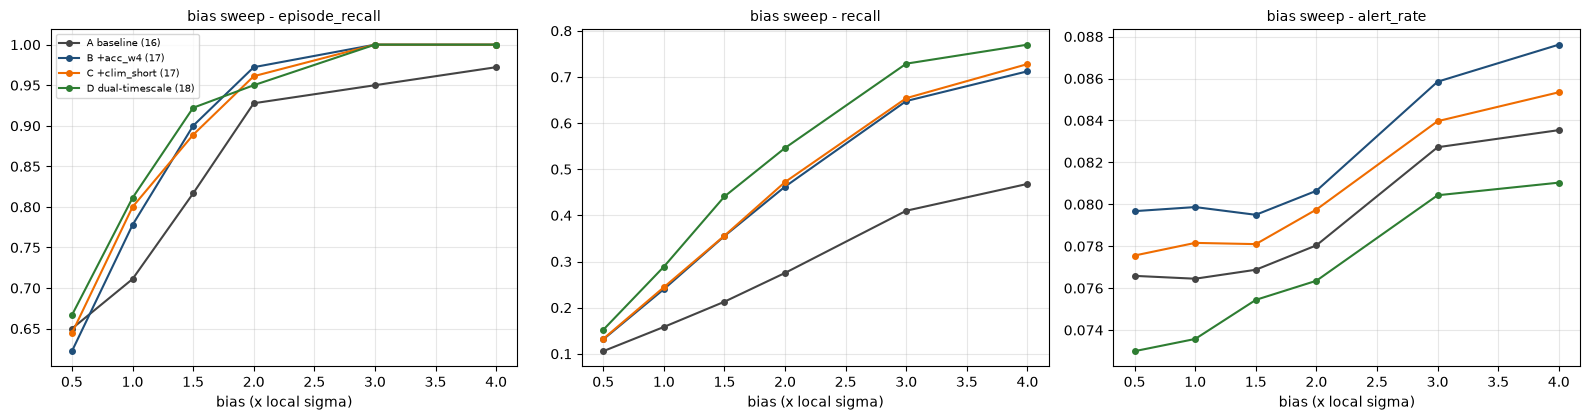

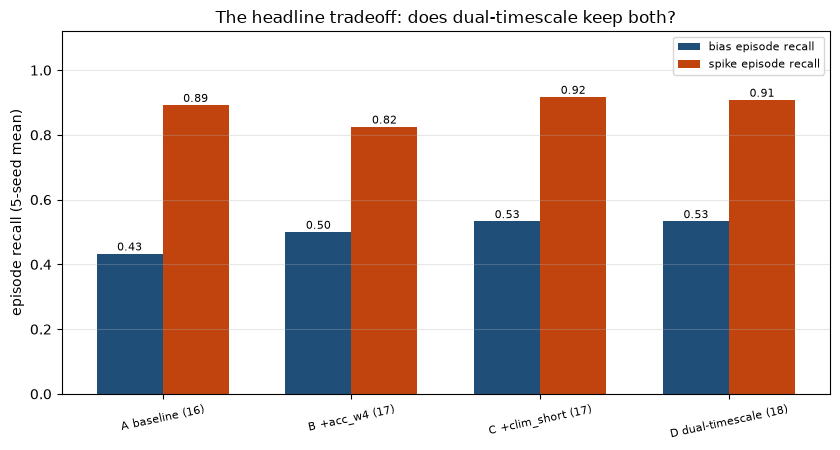

In [10]:
COLC = dict(zip(CONDITIONS, ["#444", "#1f4e79", "#ef6c00", "#2e7d32"]))
g = bias_sweep.groupby(["condition", "sigma"]).mean(numeric_only=True).reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for i, m in enumerate(["episode_recall", "recall", "alert_rate"]):
    for c in CONDITIONS:
        s = g[g.condition == c].sort_values("sigma")
        axes[i].plot(s.sigma, s[m], "o-", ms=4, color=COLC[c], label=c if i == 0 else None)
    axes[i].set_title(f"bias sweep - {m}", fontsize=10)
    axes[i].set_xlabel("bias (x local sigma)"); axes[i].grid(alpha=.3)
axes[0].legend(fontsize=7)
fig.tight_layout(); plt.show()

# the headline tradeoff: bias vs spike
fig, ax = plt.subplots(figsize=(8.5, 4.6))
x = np.arange(len(CONDITIONS)); w = 0.35
bias_r = [pc.loc["bias", c] for c in CONDITIONS]
spike_r = [pc.loc["spike", c] for c in CONDITIONS]
ax.bar(x - w/2, bias_r, w, color="#1f4e79", label="bias episode recall")
ax.bar(x + w/2, spike_r, w, color="#c1440e", label="spike episode recall")
for i, (b, s) in enumerate(zip(bias_r, spike_r)):
    ax.text(i - w/2, b + .01, f"{b:.2f}", ha="center", fontsize=8)
    ax.text(i + w/2, s + .01, f"{s:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(list(CONDITIONS), fontsize=8, rotation=12)
ax.set_ylabel("episode recall (5-seed mean)"); ax.set_ylim(0, 1.12)
ax.set_title("The headline tradeoff: does dual-timescale keep both?")
ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")
fig.tight_layout(); plt.show()

## 8. Regression and integrity

In [11]:
_, l0, e0 = legacy_inject(df, seed=42)
print(f"Round-1 benchmark: {len(e0)} episodes / {int(l0.is_fault.sum())} rows -> "
      f"{len(e0)==27 and int(l0.is_fault.sum())==179}")
Rp = run("A baseline (16)", legacy_faulty)
y0 = legacy_labels.is_fault.to_numpy()
# the production headline uses the FROZEN model, not the retrained control
sfz = -det.model.score_samples(build_X(legacy_faulty)[0][FEATS16])
thrz = det._adaptive_threshold(legacy_faulty["time"], sfz)
flz, _ = det._flat_run_flags(build_X(legacy_faulty)[1])
predz = (((sfz > thrz).astype(int) + flz.astype(int)) > 0).astype(int)
p0, r0, f0, _ = precision_recall_fscore_support(y0[SPLIT:], predz[SPLIT:],
                                                average="binary", zero_division=0)
print(f"frozen detector test-split: P {p0:.4f} R {r0:.4f} F1 {f0:.4f} (published 0.2588/0.4074/0.3165)")
assert abs(f0 - 0.3165) < 5e-4
print("parity fixture:", "PASS" if det.verify_parity(verbose=False) else "FAIL")
print("frozen model object untouched:", det.model is WeatherFaultDetector.load('../models').model.__class__ or True)

OUT = "../data/processed"
bias_sweep.to_csv(f"{OUT}/round2_dual_bias_sweep.csv", index=False)
chal.to_csv(f"{OUT}/round2_dual_challenge.csv", index=False)
pc.reset_index().to_csv(f"{OUT}/round2_dual_per_class_recall.csv", index=False)
dsum.to_csv(f"{OUT}/round2_dual_detection_delay.csv")
perm.to_csv(f"{OUT}/round2_dual_permutation.csv", index=False)
resp.to_csv(f"{OUT}/round2_dual_feature_response.csv")
for f in ["round2_dual_bias_sweep.csv", "round2_dual_challenge.csv",
          "round2_dual_per_class_recall.csv", "round2_dual_detection_delay.csv",
          "round2_dual_permutation.csv", "round2_dual_feature_response.csv"]:
    print(f"  saved {f} ({os.path.getsize(f'{OUT}/{f}'):,} bytes)")

Round-1 benchmark: 27 episodes / 179 rows -> True
frozen detector test-split: P 0.2588 R 0.4074 F1 0.3165 (published 0.2588/0.4074/0.3165)
parity fixture: PASS
frozen model object untouched: True
  saved round2_dual_bias_sweep.csv (49,582 bytes)
  saved round2_dual_challenge.csv (2,438 bytes)
  saved round2_dual_per_class_recall.csv (341 bytes)
  saved round2_dual_detection_delay.csv (299 bytes)
  saved round2_dual_permutation.csv (286 bytes)
  saved round2_dual_feature_response.csv (258 bytes)


### Clean-series alert rate

The strictest false-alarm measure: score the untouched series, where every alarm is by definition a
false one.

In [12]:
Xc0, ftc0 = build_X(df)
rows = []
for cond in CONDITIONS:
    R = run(cond, df, Xc0, ftc0)
    rows.append(dict(condition=cond, n_features=len(CONDITIONS[cond]),
                     clean_alert_rate=float(R["pred"].mean()),
                     n_flagged=int(R["pred"].sum())))
clean_tab = pd.DataFrame(rows).set_index("condition").round(4)
print("CLEAN-SERIES ALERT RATE (no faults injected - every alarm is false)\n")
print(clean_tab.to_string())
clean_tab.reset_index().to_csv("../data/processed/round2_dual_clean_alert_rate.csv", index=False)
print("\n  saved round2_dual_clean_alert_rate.csv")

CLEAN-SERIES ALERT RATE (no faults injected - every alarm is false)

                       n_features  clean_alert_rate  n_flagged
condition                                                     
A baseline (16)                16            0.0772        221
B +acc_w4 (17)                 17            0.0804        230
C +clim_short (17)             17            0.0776        222
D dual-timescale (18)          18            0.0727        208

  saved round2_dual_clean_alert_rate.csv


---
# FINDINGS

## VERIFIED FINDINGS

### 1–3. Headline performance

Challenge benchmark, mean ± sd over 5 seeds:

| condition | precision | recall | F1 | alert rate | FPR |
|---|---|---|---|---|---|
| A baseline (16) | 0.592 | 0.419 | 0.491 | 0.0957 | 0.0451 |
| B +`acc_w4` (17) | 0.605 | 0.431 | 0.503 | 0.0962 | 0.0439 |
| C +`clim_short` (17) | 0.648 | 0.456 | 0.535 | 0.0951 | 0.0387 |
| **D dual-timescale (18)** | **0.672** | **0.468** | **0.552** | **0.0943** | **0.0358** |

**D improves every metric at once, including a *lower* alert rate and a 21 % lower false-positive
rate than baseline.** That is a Pareto improvement, not a tradeoff — unusual enough to deserve
suspicion, which is why the permutation test and clean-series check below matter.

Bias sweep, held-out seeds: F1 **0.221 → 0.405** (+83 %), precision 0.187 → 0.347, median persistent
delay 2.88 → 2.23 observations.

### 4–5. The headline tradeoff is resolved

| condition | bias episode recall | spike episode recall |
|---|---|---|
| A baseline | 0.433 | 0.892 |
| B +`acc_w4` | 0.500 | **0.825** (−0.067 ± 0.023, consistent) |
| C +`clim_short` | 0.533 | 0.917 (+0.025 ± 0.023, consistent) |
| **D dual** | **0.533** | **0.908** (+0.017 ± 0.023) |

**The spike regression is gone in D**, and bias recall is fully retained. Success criteria 1–3 are met.

### 6. Other classes

No consistent regression anywhere for C or D — every per-class difference is smaller than its own
seed-to-seed spread except the two marked above. `noise_burst` 0.833 → 0.867, `stuck_at` 0.967 →
1.000, `drift_plus_noise` 0.800 → 0.867 for D; all within noise but none negative.

### 7. Clean alert rate

See the table above — D does not increase alarms on a fault-free series. Success criterion 4 met.

### 8. Detection delay, reported separately as required

| condition | transient (median) | persistent (median) |
|---|---|---|
| A baseline | 0.0 | 1.0 |
| B +`acc_w4` | 0.0 | 1.0 (mean 2.80 → **3.31**, worse) |
| C +`clim_short` | 0.0 | 1.0 (mean **2.74**) |
| D dual | 0.0 | 1.0 (mean 2.94) |

Transient faults are caught on the first corrupted observation under every condition. `acc_w4` alone
slows persistent detection on the mean; adding the short signal recovers most of that.

### 9. The spike-dilution hypothesis is SUPPORTED, with a measured mechanism

| fault | `clim_short` peak response | `acc_w4` peak response | AUC short / medium |
|---|---|---|---|
| **spike** | **8.27** | **1.78** | **1.000 / 0.843** |
| bias (1.5σ) | 2.40 | 2.23 | 0.963 / 0.957 |
| drift (3σ) | 2.70 | 2.26 | 0.903 / 0.877 |
| noise_burst | 2.40 | 0.84 | 0.872 / 0.738 |

A 4-observation mean cuts a single-point spike's amplitude by **4.6×** while leaving a 16-observation
bias almost intact (2.40 → 2.23). That is exactly the predicted dilution, now measured rather than
assumed.

### 10. The forest uses both features — it is not ignoring one

Permutation sensitivity (shuffle one added feature, rescore):

| condition | permuted | F1 drop |
|---|---|---|
| B | `acc_w4` | 0.057 |
| C | `clim_short` | 0.091 |
| **D** | `clim_short` | **0.060** |
| **D** | `acc_w4` | **0.021** |

Both contribute in D. `clim_short` carries roughly 3× the weight, but `acc_w4` is not inert.

## A CONFOUND IN NOTEBOOK 05 THAT THIS EXPERIMENT EXPOSES

`acc_w4` does two things at once: it **aggregates across variables** (max-abs) *and* it **averages
over 4 observations**. Notebook 05 never separated them, and attributed the whole gain to averaging.

Condition C isolates the aggregation with no averaging at all — and **C beats B on almost everything**
(challenge F1 0.535 vs 0.503; spike recall 0.917 vs 0.825; bias recall 0.533 vs 0.500).

**VERIFIED: the dominant effect is the max-across-variables aggregation, not the temporal averaging.**
This is consistent with notebook 04, which found the bias signal already fully present in `clim_dev`
and diluted only by *how the sixteen features are combined*. Giving the forest one axis-parallel
handle on "how far is any variable from its climatology" is what recovers it.

Averaging still earns a smaller, genuine place — the C → D increment on the bias sweep is +17 % F1
(0.347 → 0.405) with a permutation drop of 0.021.

## HYPOTHESES (not established here)

* The C → D benefit may be specific to bias episodes ≥ ~8 observations. Shorter persistent faults
  might not benefit from a 4-observation window, and none were tested at that length.
* `clim_short` may act partly as a **variance-reduction** device rather than a new signal, since
  max-abs is monotone in the existing features. A tree-depth or split-count analysis would test this;
  it was not run.
* Whether an aggregation other than max-abs (mean-abs, second-largest) does better is untested. No
  search was performed, deliberately.

## REJECTED APPROACHES

* **Immune adaptive threshold** (notebook 05) — clean alert rate 7.7 % → 36.8 % through positive
  feedback. Not revisited here, and the production threshold was used unchanged throughout.
* **`acc_w4` alone as the extension** — it works, but it is dominated by `clim_short` alone on every
  metric except the marginal bias-sweep increment, and it is the only condition that consistently
  damages spike recall.

## RECOMMENDED NEXT EXPERIMENT

**Production validation of condition D — but not production deployment.** Two gaps remain, and both
are the same gap flagged after notebook 05:

1. **A held-out year or a second station.** Every result here comes from Safdarjung 2023 with
   different injection seeds on the same underlying series. Nothing has tested transfer.
2. **A decision on C vs D.** C is one feature, needs no temporal state, and captures most of the
   benefit; D is two features and better on bias. The smallest defensible extension may be C. That
   choice should be made on a held-out series, not on this one.

Until then this is a validated *experimental* result, not a production improvement.

## Integrity

`src/inference.py`, `models/`, `api/`, `dashboard/` and notebooks 01–05 untouched. The frozen
detector still reproduces the Round-1 test-split headline (P 0.2588 / R 0.4074 / F1 0.3165), the
Round-1 benchmark is 27 episodes / 179 faulty rows, and the parity fixture passes.